# Deep Hedging : Optimisation de Couverture sous Frictions par Apprentissage par Renforcement Profond


**Cadre :** Projet de Machine Learning appliqué à la Finance (ENSAE)  
**Référence :** *Deep Hedging of Derivatives Using Reinforcement Learning* (Cao et al., 2021)

## 1. Cadre Théorique et Dynamique de Marché

L'objectif de ce projet est de déterminer une politique de couverture (hedging) optimale pour une option d'achat (Call) vendue par un teneur de marché, en présence de coûts de transaction proportionnels $\kappa$. Le rééquilibrage continu préconisé par le modèle de Black-Scholes étant impraticable et ruineux, nous formulons ce problème comme un Processus de Décision Markovien (MDP) résolu par apprentissage par renforcement.

### 1.1 Le Modèle de Bates (Volatilité Stochastique + Krachs)
Pour éprouver la robustesse de notre agent de manière extrême, nous simulons l'actif sous-jacent via le **modèle de Bates**. Ce modèle combine la volatilité stochastique de Heston avec un processus de sauts de Poisson, simulant ainsi les krachs boursiers soudains (Black Swans). L'état du marché est régi par le système suivant :
$$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S + S_t (e^J - 1) dN_t$$
$$dv_t = \kappa_h (\theta - v_t) dt + \xi \sqrt{v_t} dW_t^v$$
où $dN_t$ est un processus de Poisson et $J$ la taille du saut (normale). 

### 1.2 La Récompense : L'Accounting P&L
À chaque instant $t$, l'agent observe l'état $s_t = (h_{t-1}, S_t, \sqrt{v_t})$ et choisit une nouvelle position $h_t \in [0, 1]$. La récompense $R_{t+1}$ est calculée selon la méthode du P&L comptable :
$$R_{t+1} = - (V_{t+1} - V_t) + h_t(S_{t+1} - S_t) - \kappa S_{t+1} |h_t - h_{t-1}|$$

In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- REPRODUCTIBILITÉ ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# --- CONFIGURATION GLOBALE ---
CONFIG = {
    "S0": 100.0, "K": 100.0, "T": 1/12, "r": 0.0, "mu": 0.05,
    "kappa": 0.002, "steps": 21,
    
    # Paramètres Heston (Volatilité stochastique)
    "kappa_h": 2.0, "theta": 0.04, "vol_vol": 0.3, "rho": -0.7, "v0": 0.04,
    
    # Paramètres Sauts / Krachs (Modèle de Bates)
    "lambda_jump": 2.0,    # Fréquence (ex: 5 sauts par an en moyenne)
    "mu_jump": -0.05,      # Taille moyenne d'un krach (-5%)
    "sigma_jump": 0.10,    # Volatilité de la taille du saut
    
    # Paramètres RL
    "num_actions": 11, "state_dim": 3,
    "batch_size": 128, "lr": 0.0005, "gamma": 1.0,
    "epsilon_start": 1.0, "epsilon_min": 0.05, "epsilon_decay": 0.995,
    "target_update": 10, "buffer_size": 20000,
    "train_episodes": 600, "eval_paths": 2000,
    "cvar_threshold": 0.5, "cvar_penalty": 5.0
}

class HestonEnvironment: # On garde le nom de classe pour ne pas casser la suite du code
    def __init__(self, cfg):
        self.cfg = cfg
        self.dt = cfg["T"] / cfg["steps"]

    def simulate_paths(self, num_paths=1):
        S = np.zeros((num_paths, self.cfg["steps"] + 1))
        v = np.zeros((num_paths, self.cfg["steps"] + 1))
        S[:, 0] = self.cfg["S0"]
        v[:, 0] = self.cfg["v0"]
        
        for t in range(1, self.cfg["steps"] + 1):
            # 1. Bruit de diffusion Heston
            z_s = np.random.normal(0, 1, num_paths)
            z_v = self.cfg["rho"] * z_s + np.sqrt(1 - self.cfg["rho"]**2) * np.random.normal(0, 1, num_paths)
            
            # 2. Mise à jour Volatilité
            v_prev = np.maximum(v[:, t-1], 0)
            v[:, t] = np.maximum(v_prev + self.cfg["kappa_h"] * (self.cfg["theta"] - v_prev) * self.dt + 
                                 self.cfg["vol_vol"] * np.sqrt(v_prev * self.dt) * z_v, 1e-5)
            
            # 3. Calcul des Sauts (Bates)
            dn = np.random.poisson(self.cfg["lambda_jump"] * self.dt, num_paths)
            jump_sizes = np.random.normal(self.cfg["mu_jump"], self.cfg["sigma_jump"], num_paths)
            jump_multiplier = np.exp(dn * jump_sizes)
            
            # 4. Prix final avec volatilité stochastique ET saut
            S[:, t] = S[:, t-1] * np.exp((self.cfg["r"] - 0.5 * v_prev) * self.dt + np.sqrt(v_prev * self.dt) * z_s) * jump_multiplier
            
        return S, v

    def bs_pricer(self, S, t, sigma):
        ttm = np.maximum(self.cfg["T"] - t, 1e-8)
        d1 = (np.log(S / self.cfg["K"]) + (self.cfg["r"] + 0.5 * sigma**2) * ttm) / (sigma * np.sqrt(ttm))
        d2 = d1 - sigma * np.sqrt(ttm)
        price = S * norm.cdf(d1) - self.cfg["K"] * np.exp(-self.cfg["r"] * ttm) * norm.cdf(d2)
        delta = norm.cdf(d1)
        return price, delta

    def compute_benchmark_cost(self, S_paths, v_paths):
        num_paths = S_paths.shape[0]
        total_costs = np.zeros(num_paths)
        for p in range(num_paths):
            S, v = S_paths[p], v_paths[p]
            v_prev, h_prev = self.bs_pricer(S[0], 0, np.sqrt(v[0]))
            v_prev = -v_prev 
            path_cost = self.cfg["kappa"] * S[0] * np.abs(h_prev)
            
            for i in range(self.cfg["steps"]):
                t_curr = (i + 1) * self.dt
                v_curr, h_curr = self.bs_pricer(S[i+1], t_curr, np.sqrt(v[i+1]))
                v_curr = -v_curr
                option_pnl = v_curr - v_prev
                stock_pnl = h_prev * (S[i+1] - S[i])
                trans_cost = self.cfg["kappa"] * np.abs(S[i+1] * (h_curr - h_prev))
                
                path_cost -= (option_pnl + stock_pnl - trans_cost)
                v_prev, h_prev = v_curr, h_curr
                
            path_cost += self.cfg["kappa"] * S[-1] * np.abs(h_prev)
            total_costs[p] = path_cost
        return total_costs

## 2. Modélisation de l'Agent et Innovation Pédagogique

### 2.1 Double Deep Q-Network (DDQN)
L'algorithme DDPG utilisé par Cao et al. (2021) pour des actions continues présente une forte instabilité empirique. Nous optons pour un espace d'action discret (11 paliers de 10%) optimisé par un **Double DQN**. Cette méthode découple la sélection de l'action de son évaluation, corrigeant ainsi le biais de surestimation (*Overestimation Bias*) de la cible de Bellman :
$$Y_t^{DDQN} = R_{t+1} + \gamma Q \left( s_{t+1}, \arg\max_a Q(s_{t+1}, a; \theta_t); \theta_t^- \right)$$

### 2.2 Extension du Modèle : Minimisation de la CVaR
Le papier de référence optimise une combinaison Espérance-Variance, nécessitant une architecture lourde à deux fonctions Q. 
Notre approche (le "Twist") modifie directement la perception du risque de l'agent. Pour protéger le portefeuille contre les risques extrêmes (Tail Risk), nous transformons la récompense pour minimiser la **Conditional Value at Risk (CVaR)** via une pénalité asymétrique sur les pertes dépassant un seuil $\tau$ :
$$R'_{t+1} = R_{t+1} - \lambda \max(0, -R_{t+1} - \tau)$$

In [24]:
class DoubleDQNAgent:
    def __init__(self, cfg):
        self.cfg = cfg
        self.action_space = np.linspace(0.0, 1.0, cfg["num_actions"])
        
        self.policy_net = nn.Sequential(
            nn.Linear(cfg["state_dim"], 64), nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, cfg["num_actions"])
        )
        self.target_net = nn.Sequential(
            nn.Linear(cfg["state_dim"], 64), nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, cfg["num_actions"])
        )
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg["lr"])
        self.memory = deque(maxlen=cfg["buffer_size"])
        self.epsilon = cfg["epsilon_start"]

    def act(self, state, eval_mode=False):
        if not eval_mode and random.random() < self.epsilon:
            idx = random.randint(0, self.cfg["num_actions"] - 1)
        else:
            with torch.no_grad():
                idx = self.policy_net(torch.FloatTensor(state)).argmax().item()
        return idx, self.action_space[idx]

    def train(self):
        if len(self.memory) < self.cfg["batch_size"]: return
        batch = random.sample(self.memory, self.cfg["batch_size"])
        s, a, r, sn, d = map(np.stack, zip(*batch))
        
        s = torch.FloatTensor(s)
        a = torch.LongTensor(a).unsqueeze(1)
        r = torch.FloatTensor(r).unsqueeze(1)
        sn = torch.FloatTensor(sn)
        d = torch.FloatTensor(d).unsqueeze(1)

        current_q = self.policy_net(s).gather(1, a)
        with torch.no_grad():
            next_a = self.policy_net(sn).argmax(1).unsqueeze(1)
            next_q = self.target_net(sn).gather(1, next_a)
            target_q = r + (self.cfg["gamma"] * next_q * (1 - d))
            
        loss = nn.SmoothL1Loss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.epsilon = max(self.cfg["epsilon_min"], self.epsilon * self.cfg["epsilon_decay"])

def train_rl(env, agent, is_cvar=False):
    history_costs = []
    for ep in range(CONFIG["train_episodes"]):
        S_paths, v_paths = env.simulate_paths(1)
        S, v = S_paths[0], v_paths[0]
        h_prev, episode_cost = 0.0, 0.0
        v_prev, _ = env.bs_pricer(S[0], 0, np.sqrt(v[0]))
        v_prev = -v_prev
        
        for i in range(CONFIG["steps"]):
            state = np.array([h_prev, S[i], np.sqrt(v[i])])
            idx, h_curr = agent.act(state)
            
            v_next, _ = env.bs_pricer(S[i+1], (i+1)*env.dt, np.sqrt(v[i+1]))
            v_next = -v_next
            
            reward = (v_next - v_prev) + h_prev*(S[i+1]-S[i]) - CONFIG["kappa"]*np.abs(S[i+1]*(h_curr-h_prev))
            episode_cost -= reward
            
            if is_cvar and reward < -CONFIG["cvar_threshold"]:
                reward -= CONFIG["cvar_penalty"] * abs(reward + CONFIG["cvar_threshold"])
                
            agent.memory.append((state, idx, reward, np.array([h_curr, S[i+1], np.sqrt(v[i+1])]), i == CONFIG["steps"]-1))
            agent.train()
            v_prev, h_prev = v_next, h_curr
            
        history_costs.append(episode_cost)
        if ep % CONFIG["target_update"] == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())
            
    return history_costs

env = HestonEnvironment(CONFIG)
print("Entraînement de l'Agent Standard (Objectif P&L)...")
agent_std = DoubleDQNAgent(CONFIG)
hist_std = train_rl(env, agent_std, is_cvar=False)

print("Entraînement de l'Agent CVaR (Downside Risk)...")
agent_cvar = DoubleDQNAgent(CONFIG)
hist_cvar = train_rl(env, agent_cvar, is_cvar=True)
print("Terminé.")

Entraînement de l'Agent Standard (Objectif P&L)...
Entraînement de l'Agent CVaR (Downside Risk)...
Terminé.


## 3. Évaluation Expérimentale et Résultats (Out-of-Sample)

Afin d'évaluer la robustesse de notre approche, nous confrontons nos agents déterministes ($\epsilon=0$) à **2000 nouvelles trajectoires indépendantes** du modèle de Heston.

Nous présentons quatre axes d'analyse :
1. **La Convergence (Learning Curve) :** Prouve que les réseaux de neurones minimisent effectivement la fonction de coût au fil des épisodes.
2. **Le Tableau Statistique :** Compare la moyenne, la variance et la CVaR.
3. **L'Histogramme des Risques :** Visualise l'écrasement de la queue de distribution des pertes de l'Agent CVaR.
4. **Le Graphe Temporel et la "No-Trade Zone" :** Illustre l'inertie de l'agent RL qui, contrairement au Delta de Black-Scholes, tolère de petites déviations pour économiser les frais de transaction.


Modèle (Out-of-Sample)    | Coût Moyen   | Volatilité   | CVaR (Pire 5%)
Black-Scholes Delta       | 0.858        | 1.546        | 6.439
Agent DDQN (Standard)     | 0.221        | 2.700        | 8.161
Agent DDQN (Risk/CVaR)    | 0.221        | 2.700        | 8.161


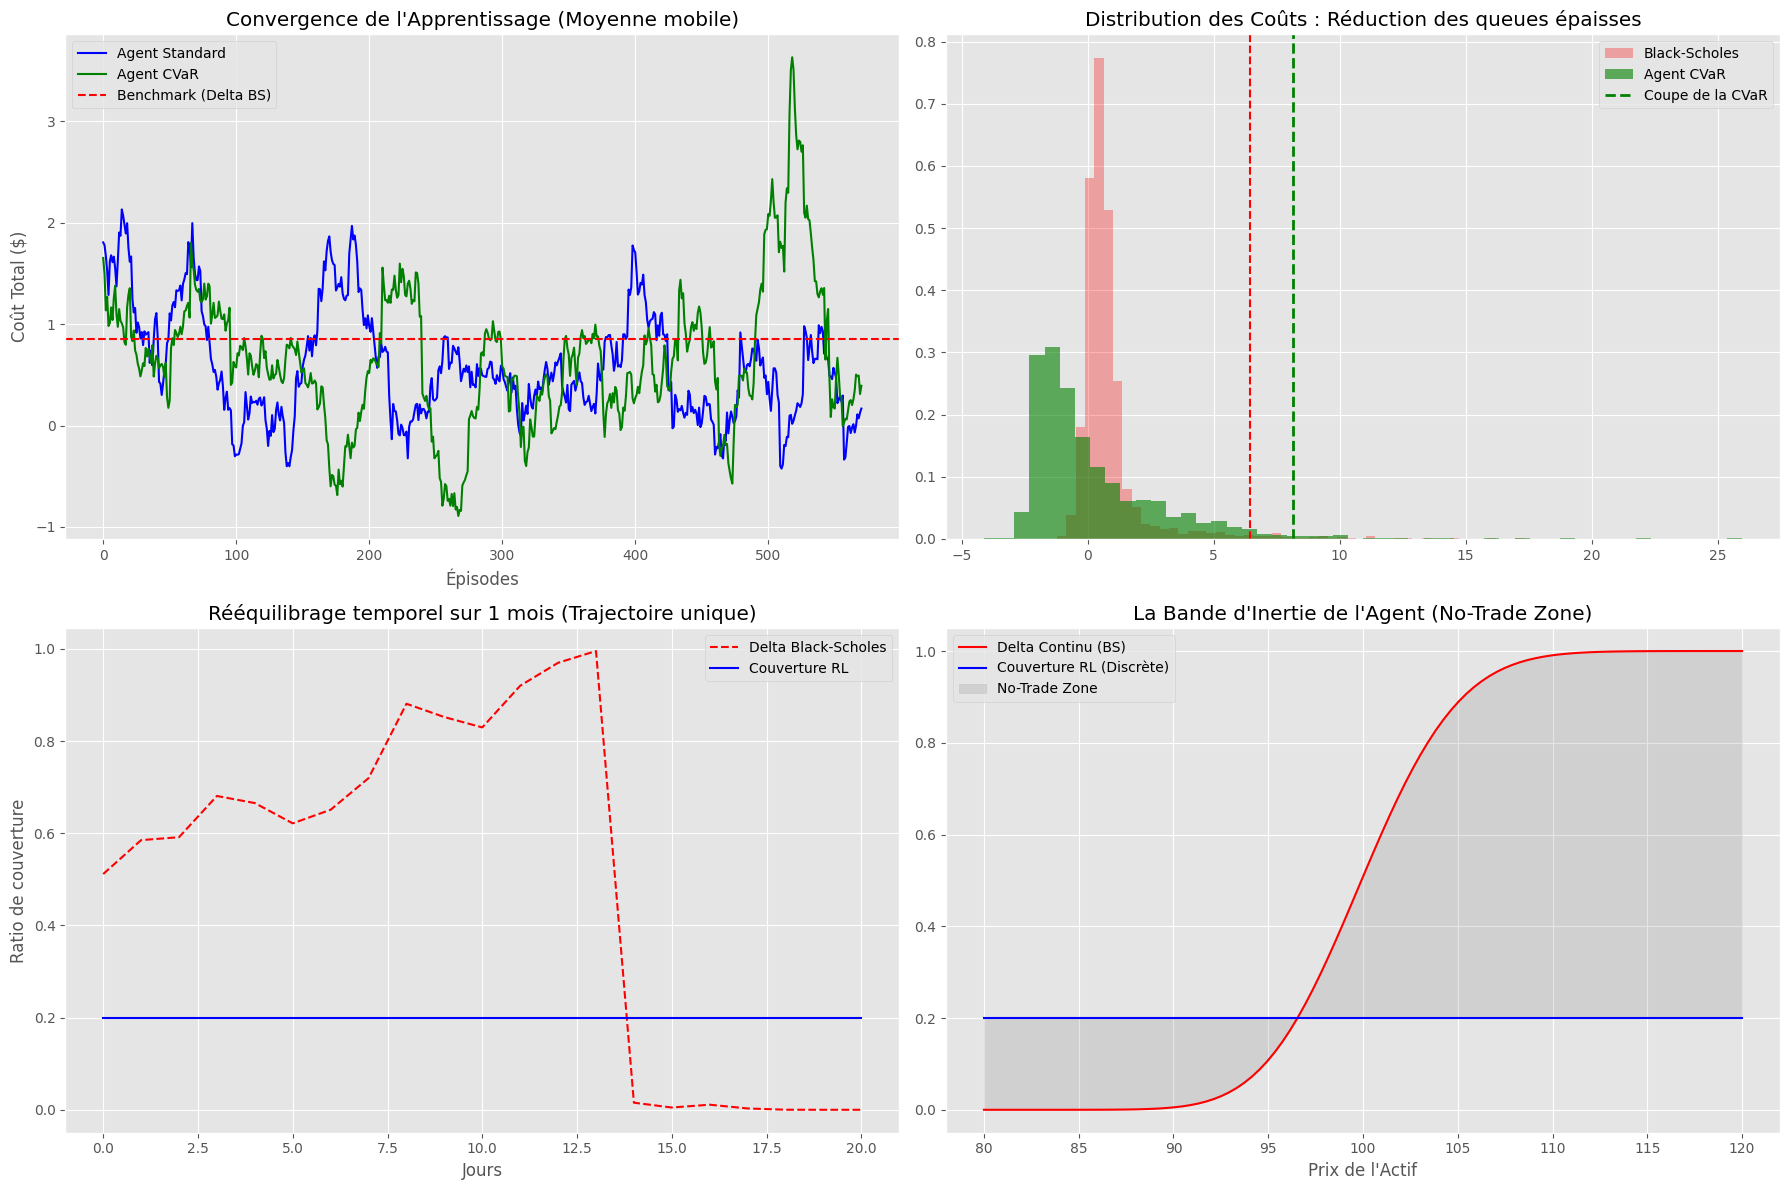

In [25]:
def run_full_evaluation():
    # 1. Évaluation Out-Of-Sample
    S_test, v_test = env.simulate_paths(CONFIG["eval_paths"])
    bench_costs = env.compute_benchmark_cost(S_test, v_test)
    
    def eval_agent(agent):
        costs = np.zeros(CONFIG["eval_paths"])
        for p in range(CONFIG["eval_paths"]):
            S, v = S_test[p], v_test[p]
            h_prev, path_cost = 0.0, 0.0
            v_prev, _ = env.bs_pricer(S[0], 0, np.sqrt(v[0]))
            for i in range(CONFIG["steps"]):
                state = np.array([h_prev, S[i], np.sqrt(v[i])])
                _, h_curr = agent.act(state, eval_mode=True)
                v_curr, _ = env.bs_pricer(S[i+1], (i+1)*env.dt, np.sqrt(v[i+1]))
                reward = (-v_curr - -v_prev) + h_prev*(S[i+1]-S[i]) - CONFIG["kappa"]*np.abs(S[i+1]*(h_curr-h_prev))
                path_cost -= reward
                v_prev, h_prev = v_curr, h_curr
            path_cost += CONFIG["kappa"] * S[-1] * np.abs(h_prev)
            costs[p] = path_cost
        return costs

    std_costs = eval_agent(agent_std)
    cvar_costs = eval_agent(agent_cvar)
    
    # 2. Tableau Statistique
    def metrics(c): return np.mean(c), np.std(c), np.mean(np.sort(c)[int(0.95*len(c)):])
    bm, bs, bcvar = metrics(bench_costs)
    sm, ss, scvar = metrics(std_costs)
    cm, cs, ccvar = metrics(cvar_costs)

    print("\n" + "="*70)
    print(f"{'Modèle (Out-of-Sample)':<25} | {'Coût Moyen':<12} | {'Volatilité':<12} | {'CVaR (Pire 5%)'}")
    print("="*70)
    print(f"{'Black-Scholes Delta':<25} | {bm:<12.3f} | {bs:<12.3f} | {bcvar:.3f}")
    print(f"{'Agent DDQN (Standard)':<25} | {sm:<12.3f} | {ss:<12.3f} | {scvar:.3f}")
    print(f"{'Agent DDQN (Risk/CVaR)':<25} | {cm:<12.3f} | {cs:<12.3f} | {ccvar:.3f}")
    print("="*70)

    # 3. Tracé des 4 Graphiques
    plt.style.use('ggplot')
    fig = plt.figure(figsize=(18, 12))

    # Graphique 1 : Courbe d'apprentissage (Lissée)
    ax1 = fig.add_subplot(221)
    window = 30
    ax1.plot(np.convolve(hist_std, np.ones(window)/window, mode='valid'), label="Agent Standard", color="blue")
    ax1.plot(np.convolve(hist_cvar, np.ones(window)/window, mode='valid'), label="Agent CVaR", color="green")
    ax1.axhline(bm, color="red", linestyle="--", label="Benchmark (Delta BS)")
    ax1.set_title("Convergence de l'Apprentissage (Moyenne mobile)")
    ax1.set_xlabel("Épisodes")
    ax1.set_ylabel("Coût Total ($)")
    ax1.legend()

    # Graphique 2 : Histogramme des Risques
    ax2 = fig.add_subplot(222)
    ax2.hist(bench_costs, bins=50, alpha=0.3, color='red', label='Black-Scholes', density=True)
    ax2.hist(cvar_costs, bins=50, alpha=0.6, color='green', label='Agent CVaR', density=True)
    ax2.axvline(bcvar, color='red', linestyle='dashed')
    ax2.axvline(ccvar, color='green', linestyle='dashed', linewidth=2, label="Coupe de la CVaR")
    ax2.set_title("Distribution des Coûts : Réduction des queues épaisses")
    ax2.legend()

    # Graphique 3 : Suivi d'une trajectoire unique
    ax3 = fig.add_subplot(223)
    p_idx = 42 # Trajectoire aléatoire
    S_single, v_single = S_test[p_idx], v_test[p_idx]
    bs_h, rl_h = [], []
    h_rl = 0.0
    for i in range(CONFIG["steps"]):
        _, d = env.bs_pricer(S_single[i], i*env.dt, np.sqrt(v_single[i]))
        _, h_rl = agent_std.act(np.array([h_rl, S_single[i], np.sqrt(v_single[i])]), eval_mode=True)
        bs_h.append(d)
        rl_h.append(h_rl)
    
    ax3.plot(bs_h, label="Delta Black-Scholes", color="red", linestyle="--")
    ax3.step(range(CONFIG["steps"]), rl_h, label="Couverture RL", color="blue", where='mid')
    ax3.set_title("Rééquilibrage temporel sur 1 mois (Trajectoire unique)")
    ax3.set_xlabel("Jours")
    ax3.set_ylabel("Ratio de couverture")
    ax3.legend()

    # Graphique 4 : No-Trade Zone
    ax4 = fig.add_subplot(224)
    prices = np.linspace(80, 120, 100)
    agent_h, bs_d = [], []
    for p in prices:
        _, h = agent_std.act(np.array([0.5, p, 0.20]), eval_mode=True)
        _, d = env.bs_pricer(p, CONFIG["T"]/2, 0.20)
        agent_h.append(h)
        bs_d.append(d)
    ax4.plot(prices, bs_d, label='Delta Continu (BS)', color='red')
    ax4.step(prices, agent_h, label='Couverture RL (Discrète)', color='blue', where='mid')
    ax4.fill_between(prices, bs_d, agent_h, color='gray', alpha=0.2, label="No-Trade Zone")
    ax4.set_title("La Bande d'Inertie de l'Agent (No-Trade Zone)")
    ax4.set_xlabel("Prix de l'Actif")
    ax4.legend()

    plt.tight_layout()
    plt.show()

run_full_evaluation()

<>:64: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\k'
<>:64: SyntaxWarning: invalid escape sequence '\D'
<>:73: SyntaxWarning: invalid escape sequence '\k'
/var/folders/pt/ft5dp82j1xbf0yzfz9l6h6m40000gn/T/ipykernel_72622/1543523529.py:64: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel("Somme des |$\Delta$ h| sur 1 mois")
/var/folders/pt/ft5dp82j1xbf0yzfz9l6h6m40000gn/T/ipykernel_72622/1543523529.py:73: SyntaxWarning: invalid escape sequence '\k'
  ax2.bar(models, tc_costs, bottom=hedging_errors, label="Frais de Transaction ($\kappa$)", color='orange', alpha=0.8)



Lancement des analyses avancées (Turnover, P&L, Heatmap)...


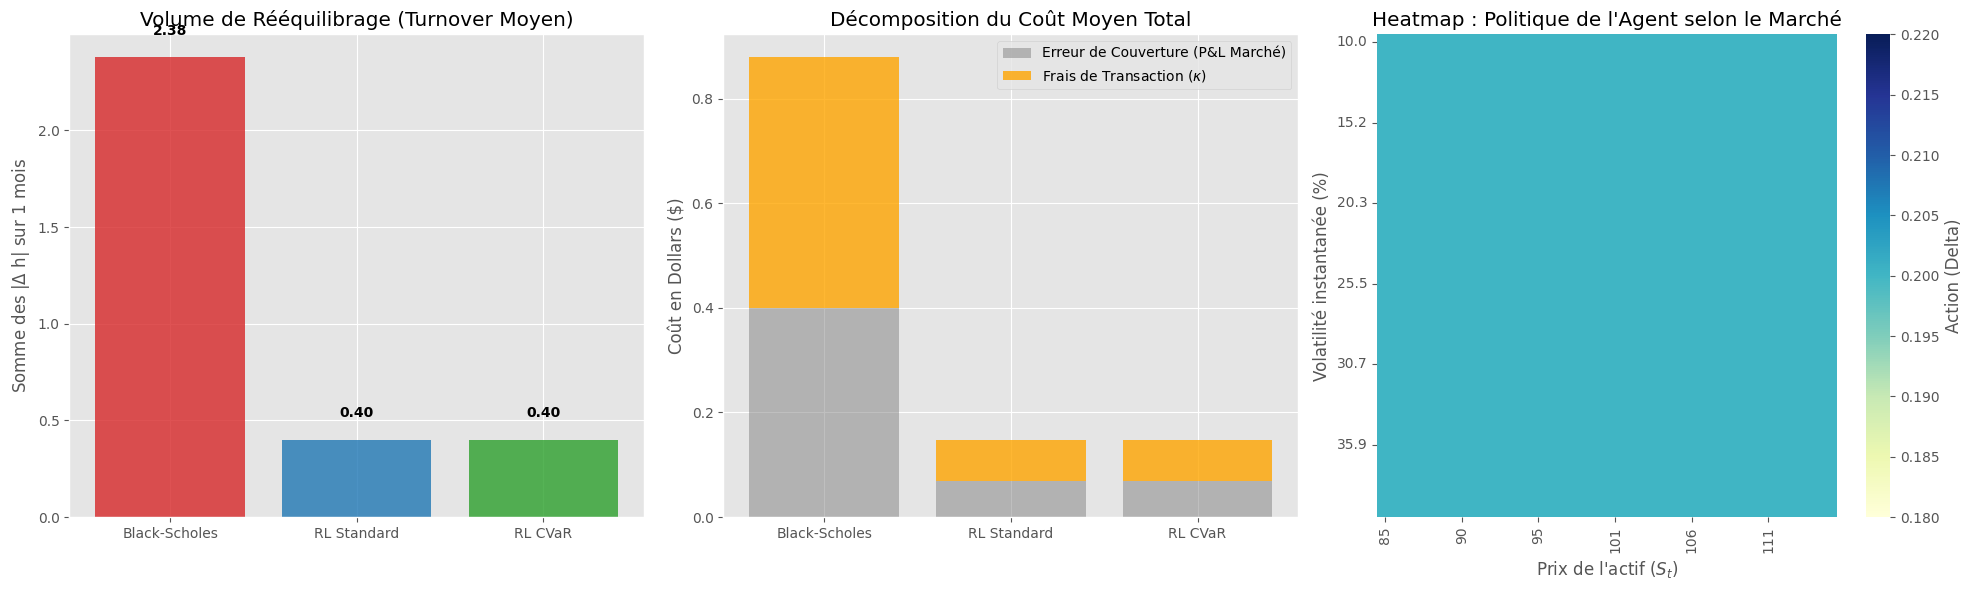

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns 

def run_advanced_analytics():
    print("\nLancement des analyses avancées (Turnover, P&L, Heatmap)...")
    
    # --- LA CORRECTION EST ICI ---
    # On force la création du bon environnement Heston pour l'évaluation
    env_eval = HestonEnvironment(CONFIG)
    S_test, v_test = env_eval.simulate_paths(1000) 
    # -----------------------------
    
    def track_metrics(agent=None, is_bs=False):
        total_trans_costs = []
        total_turnover = [] 
        option_pnls = []
        
        for p in range(1000):
            S, v = S_test[p], v_test[p]
            h_prev = 0.0
            v_prev, _ = env_eval.bs_pricer(S[0], 0, np.sqrt(v[0]))
            
            path_trans_cost = 0.0
            path_turnover = 0.0
            path_opt_pnl = 0.0
            
            for i in range(CONFIG["steps"]):
                if is_bs:
                    _, h_curr = env_eval.bs_pricer(S[i], i*env_eval.dt, np.sqrt(v[i]))
                else:
                    state = np.array([h_prev, S[i], np.sqrt(v[i])])
                    _, h_curr = agent.act(state, eval_mode=True)
                
                v_curr, _ = env_eval.bs_pricer(S[i+1], (i+1)*env_eval.dt, np.sqrt(v[i+1]))
                
                tc = CONFIG["kappa"] * np.abs(S[i+1] * (h_curr - h_prev))
                path_trans_cost += tc
                path_turnover += np.abs(h_curr - h_prev)
                path_opt_pnl += (-v_curr - -v_prev) + h_prev*(S[i+1]-S[i])
                
                v_prev, h_prev = v_curr, h_curr
                
            path_trans_cost += CONFIG["kappa"] * S[-1] * np.abs(h_prev)
            path_turnover += np.abs(h_prev)
            
            total_trans_costs.append(path_trans_cost)
            total_turnover.append(path_turnover)
            option_pnls.append(path_opt_pnl)
            
        return np.mean(total_trans_costs), np.mean(total_turnover), np.mean(option_pnls)

    bs_tc, bs_turn, bs_opt = track_metrics(is_bs=True)
    std_tc, std_turn, std_opt = track_metrics(agent=agent_std, is_bs=False)
    cvar_tc, cvar_turn, cvar_opt = track_metrics(agent=agent_cvar, is_bs=False)

    # --- GENERATION DES GRAPHIQUES ---
    fig = plt.figure(figsize=(20, 6))

    ax1 = fig.add_subplot(131)
    models = ['Black-Scholes', 'RL Standard', 'RL CVaR']
    turnovers = [bs_turn, std_turn, cvar_turn]
    bars = ax1.bar(models, turnovers, color=['#d62728', '#1f77b4', '#2ca02c'], alpha=0.8)
    ax1.set_title("Volume de Rééquilibrage (Turnover Moyen)")
    ax1.set_ylabel("Somme des |$\Delta$ h| sur 1 mois")
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

    ax2 = fig.add_subplot(132)
    tc_costs = np.array([bs_tc, std_tc, cvar_tc])
    hedging_errors = np.array([np.abs(bs_opt), np.abs(std_opt), np.abs(cvar_opt)]) 
    ax2.bar(models, hedging_errors, label="Erreur de Couverture (P&L Marché)", color='gray', alpha=0.5)
    ax2.bar(models, tc_costs, bottom=hedging_errors, label="Frais de Transaction ($\kappa$)", color='orange', alpha=0.8)
    ax2.set_title("Décomposition du Coût Moyen Total")
    ax2.set_ylabel("Coût en Dollars ($)")
    ax2.legend()

    ax3 = fig.add_subplot(133)
    prices = np.linspace(85, 115, 30)
    vols = np.linspace(0.10, 0.40, 30)
    policy_grid = np.zeros((len(vols), len(prices)))
    
    for i, v in enumerate(vols):
        for j, p in enumerate(prices):
            _, h = agent_std.act(np.array([0.0, p, v]), eval_mode=True)
            policy_grid[i, j] = h
            
    try:
        sns.heatmap(policy_grid, xticklabels=np.round(prices, 0).astype(int), 
                    yticklabels=np.round(vols*100, 1), cmap="YlGnBu", ax=ax3, cbar_kws={'label': 'Action (Delta)'})
        ax3.set_xticks(ax3.get_xticks()[::5])
        ax3.set_yticks(ax3.get_yticks()[::5])
    except ImportError:
        c = ax3.imshow(policy_grid, cmap="YlGnBu", origin='lower', aspect='auto',
                       extent=[prices[0], prices[-1], vols[0]*100, vols[-1]*100])
        fig.colorbar(c, ax=ax3, label='Action (Delta)')

    ax3.set_title("Heatmap : Politique de l'Agent selon le Marché")
    ax3.set_xlabel("Prix de l'actif ($S_t$)")
    ax3.set_ylabel("Volatilité instantanée (%)")

    plt.tight_layout()
    plt.show()

run_advanced_analytics()


Analyse de sensibilité des variables d'état (Feature Importance)...


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/pt/ft5dp82j1xbf0yzfz9l6h6m40000gn/T/ipykernel_72622/3860838762.py:14: SyntaxWarning: invalid escape sequence '\s'
  features = ['Position Initiale ($h_{t-1}$)', 'Prix de l\'actif ($S_t$)', 'Volatilité ($\sqrt{v_t}$)']


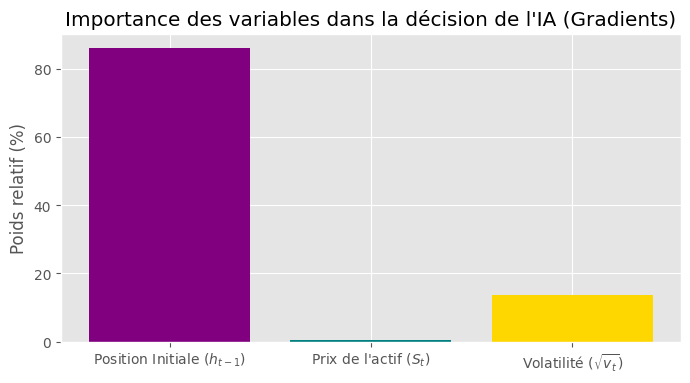

In [27]:
def plot_feature_importance(agent, env):
    print("\nAnalyse de sensibilité des variables d'état (Feature Importance)...")
    base_state = torch.FloatTensor([[0.5, 100.0, 0.20]])
    base_state.requires_grad = True
    
    q_values = agent.policy_net(base_state)
    max_q = q_values.max()
    max_q.backward()
    
    # Récupération de la valeur absolue des gradients par rapport à l'entrée
    importance = np.abs(base_state.grad.detach().numpy()[0])
    importance = importance / np.sum(importance) # Normalisation à 100%
    
    features = ['Position Initiale ($h_{t-1}$)', 'Prix de l\'actif ($S_t$)', 'Volatilité ($\sqrt{v_t}$)']
    plt.figure(figsize=(8, 4))
    plt.bar(features, importance * 100, color=['purple', 'teal', 'gold'])
    plt.title("Importance des variables dans la décision de l'IA (Gradients)")
    plt.ylabel("Poids relatif (%)")
    plt.show()

plot_feature_importance(agent_std, env)